Uploading dataset

In [1]:
import pandas as pd
file_path = "Tweets df.csv"
df = pd.read_csv(file_path)
df

,airline_sentiment,sentiment_confidence,text
0,neutral,1.0000,@VirginAmerica What @dhepburn said.
1,positive,0.3486,@VirginAmerica plus you've added commercials t...
2,neutral,0.6837,@VirginAmerica I didn't today... Must mean I n...
3,negative,1.0000,@VirginAmerica it's really aggressive to blast...
4,negative,1.0000,@VirginAmerica and it's a really big bad thing...
...,...,...,...
14634,positive,0.3487,@AmericanAir thank you we got on a different f...
14635,negative,1.0000,@AmericanAir leaving over 20 minutes Late Flig...
14636,neutral,1.0000,@AmericanAir Please bring American Airlines to...
14637,negative,1.0000,"@AmericanAir you have my money, you change my ..."


Cleaning of the dataset for better use + download the needed packages



In [2]:
!pip install contractions
!pip install emoji


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 7.1 MB/s eta 0:00:00


In [3]:
import contractions  # Expands contractions in text
import re  # Regular expressions for text cleaning
import pandas as pd  # Handles data manipulation
import emoji  # Converts emojis to text descriptions
import nltk  # Natural Language Toolkit for text processing
from nltk.corpus import stopwords  # Stopword removal
from nltk.stem import WordNetLemmatizer  # Word lemmatization


Initialise stopwords and lemmatizer


* Stopwords are common words (e.g., the, is, and) that do not contribute much to sentiment analysis.

* WordNet Lemmatizer reduces words to their base forms.





In [4]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [5]:
airline_list = ["VirginAmerica", "united", "SouthwestAir", "JetBlue", "USAirways", "AmericanAir"]


Actual cleaning function

In [6]:
def clean_text(text):
    # Convert emojis to text descriptions
    text = emoji.demojize(text, delimiters=(" ", " "))  # 😊 → " smiley face "

    # Expand contractions (e.g., "can't" → "cannot")
    text = contractions.fix(text)

    # Remove hashtags but keep words (e.g., "#happy" → "happy")
    text = re.sub(r'#(\w+)', r'\1', text)

    # Extract airline name if mentioned
    airline_pattern = r'@(' + '|'.join(airline_list) + r')\b'
    match = re.search(airline_pattern, text, re.IGNORECASE)
    airline = match.group(1) if match else "Unknown"

    # Remove airline mentions
    text = re.sub(airline_pattern, '', text, flags=re.IGNORECASE).strip()

    # Detect and remove hyperlinks
    link_pattern = r'http\S+'
    has_link = 1 if re.search(link_pattern, text) else 0
    text = re.sub(link_pattern, '', text).strip()

    # Remove punctuation and convert to lowercase
    text = re.sub(r'[^\w\s]', '', text).lower()

    # Remove stopwords and apply lemmatization
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    text = " ".join(words)

    return airline, has_link, text

In [7]:
df[['airline', 'has_link', 'clean_text']] = df['text'].apply(lambda x: pd.Series(clean_text(x)))


In [8]:
df[380:391]

,airline_sentiment,sentiment_confidence,text,airline,has_link,clean_text
380,positive,1.0000,@VirginAmerica gave a credit for my Late Fligh...,VirginAmerica,0,gave credit late flight flight yesterday great...
381,neutral,1.0000,@VirginAmerica I need a receipt for a flight c...,VirginAmerica,0,need receipt flight change send one
382,negative,1.0000,"@VirginAmerica, I submitted a status match req...",VirginAmerica,0,submitted status match request back still hear...
383,positive,1.0000,@VirginAmerica had me at their safety video . ...,VirginAmerica,1,safety video loved first cross country flight ...
384,positive,0.6871,@VirginAmerica that doesn't look to fat to me!...,VirginAmerica,0,look fat look yummy
385,neutral,1.0000,@VirginAmerica CEO says #Southwest &amp; #jetb...,VirginAmerica,1,ceo say southwest amp jetblue strayed low cost...
386,neutral,0.6811,@VirginAmerica a brilliant brisk am in Boston ...,VirginAmerica,1,brilliant brisk boston cue vx363
387,neutral,1.0000,@VirginAmerica Atlantic ploughs a lone furrow ...,VirginAmerica,1,atlantic plough lone furrow middleeast thenati...
388,neutral,1.0000,@VirginAmerica Atlantic ploughs a lone furrow ...,VirginAmerica,1,atlantic plough lone furrow middleeast thenati...
389,neutral,0.7026,@VirginAmerica Atlantic ploughs a lone furrow ...,VirginAmerica,1,atlantic plough lone furrow middleeast thenati...


DBSCAN processes now u got this

In [9]:
import numpy as np
import pandas as pd
import re
import emoji
import contractions
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from sklearn.model_selection import train_test_split

# Splitting the dataframe into 80% train and 20% test with random seed 100
df_train, df_test = train_test_split(df, test_size=0.2, random_state=100)


In [11]:
# TF-IDF Vectorization: Convert text into numerical features
vectorizer = TfidfVectorizer(max_features=1000)  # Use top 1000 most relevant words
X_tfidf = vectorizer.fit_transform(df_train['clean_text'])

# Convert to array format
X_tfidf = X_tfidf.toarray()


Step 3: Reduce Dimensionality for Better Clustering
Since TF-IDF creates a high-dimensional matrix, we use PCA (Principal Component Analysis) to reduce it to 2D for visualization.


In [12]:
# Apply PCA to reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf)

# Store PCA results in DataFrame
df_train['pca_x'] = X_pca[:, 0]
df_train['pca_y'] = X_pca[:, 1]


Apply dbscan clustering


*   eps (epsilon): Defines how close points should be to be considered a cluster. Start with 0.3 and adjust based on results.

* min_samples: Minimum points needed to form a dense region. Try 5-10 for best results.

* Noise points are labeled as -1 (outliers).



In [13]:
# Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5, metric='euclidean')  # Adjust eps and min_samples as needed
df_train['cluster'] = dbscan.fit_predict(X_tfidf)


Visualise clusters

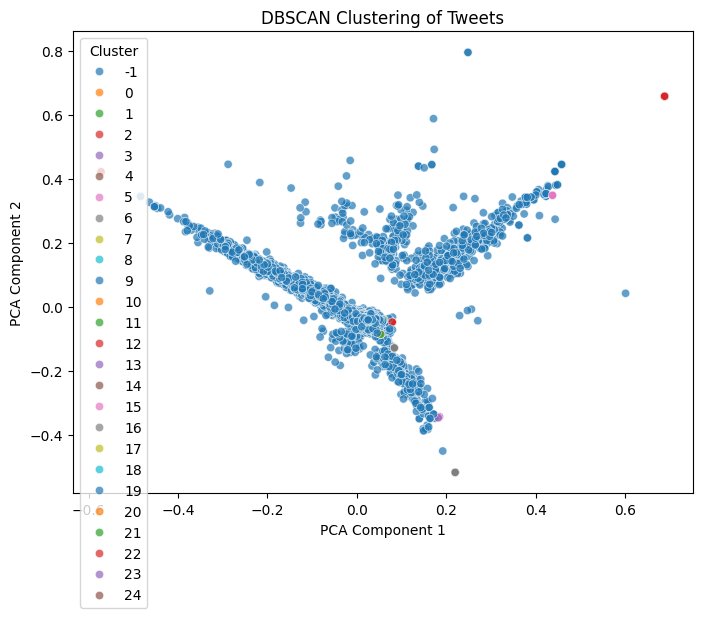

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_train['pca_x'], y=df_train['pca_y'], hue=df_train['cluster'], palette="tab10", alpha=0.7)
plt.title('DBSCAN Clustering of Tweets')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()


In [15]:
from collections import Counter

# Try different eps and min_samples values
eps_values = [0.3, 0.4]  # Try different eps values
min_samples_values = [22, 25, 28, 30, 35]  # Try different min_samples values

best_params = None
best_cluster_count = None

for eps in eps_values:
    for min_samples in min_samples_values:
        # Run DBSCAN with current parameters
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
        clusters = dbscan.fit_predict(X_tfidf)

        # Count the number of unique clusters (excluding noise)
        cluster_counts = Counter(clusters)
        num_clusters = len([c for c in cluster_counts.keys() if c != -1])  # Ignore noise (-1)

        print(f"eps: {eps}, min_samples: {min_samples}, Number of clusters: {num_clusters}")

        # Store best params if we get exactly 3 clusters
        if num_clusters == 3:
            best_params = (eps, min_samples)
            best_cluster_count = num_clusters

print("\nBest Parameters Found:", best_params)


eps: 0.3, min_samples: 22, Number of clusters: 4
eps: 0.3, min_samples: 25, Number of clusters: 4
eps: 0.3, min_samples: 28, Number of clusters: 4
eps: 0.3, min_samples: 30, Number of clusters: 4
eps: 0.3, min_samples: 35, Number of clusters: 3
eps: 0.4, min_samples: 22, Number of clusters: 4
eps: 0.4, min_samples: 25, Number of clusters: 4
eps: 0.4, min_samples: 28, Number of clusters: 4
eps: 0.4, min_samples: 30, Number of clusters: 4
eps: 0.4, min_samples: 35, Number of clusters: 3

Best Parameters Found: (0.4, 35)


Final Cluster Counts:
cluster
-1    11435
 0      136
 1       71
 2       69
Name: count, dtype: int64


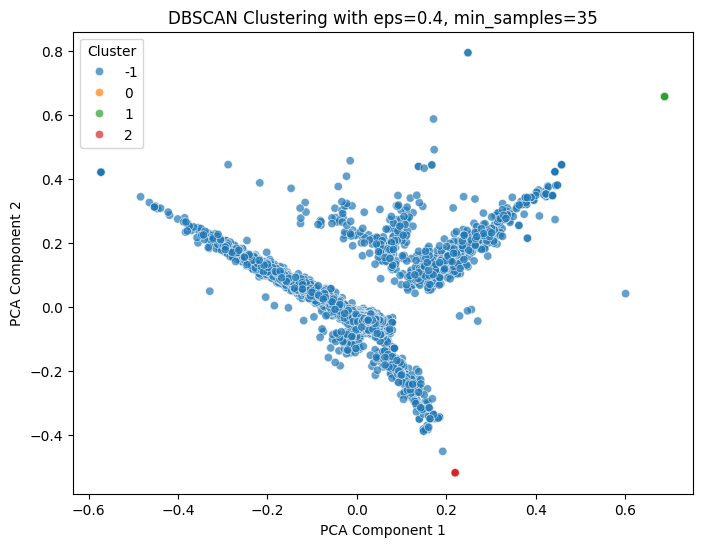

In [16]:
if best_params:
    eps, min_samples = best_params
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    df_train['cluster'] = dbscan.fit_predict(X_tfidf)

    print("Final Cluster Counts:")
    print(df_train['cluster'].value_counts())

    # Visualize Final Clustering
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df_train['pca_x'], y=df_train['pca_y'], hue=df_train['cluster'], palette="tab10", alpha=0.7)
    plt.title(f"DBSCAN Clustering with eps={eps}, min_samples={min_samples}")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend(title="Cluster")
    plt.show()


Apply on testing data

In [17]:
# Transform test data using the same vectorizer trained on df_train
X_test_tfidf = vectorizer.transform(df_test['clean_text'])


In [18]:
# Apply DBSCAN to test data
test_clusters = dbscan.fit_predict(X_test_tfidf)


In [19]:
import numpy as np
from sklearn.metrics import adjusted_rand_score

# Convert categorical sentiments to numeric values for comparison
sentiment_mapping = {'positive': 1, 'neutral': 0, 'negative': -1}
df_test['sentiment_numeric'] = df_test['airline_sentiment'].map(sentiment_mapping)

# Evaluate clustering performance using Adjusted Rand Index (ARI)
ari_score = adjusted_rand_score(df_test['sentiment_numeric'], test_clusters)

print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")


Adjusted Rand Index (ARI): 0.0000


In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

best_eps = None
best_min_samples = None
best_score = -1

eps_values = np.arange(0.1, 3.0, 0.1)  # Try different eps values
min_samples_values = range(3, 20, 2)   # Try different min_samples values

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(X_tfidf)

        # Ignore runs where everything is classified as -1 (outliers)
        if len(set(clusters)) > 1:
            score = silhouette_score(X_tfidf, clusters)
            if score > best_score:
                best_score = score
                best_eps = eps
                best_min_samples = min_samples

print(f"Best Parameters: eps={best_eps}, min_samples={best_min_samples}")


In [ ]:
from collections import Counter
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def evaluate_clustering(true_labels, predicted_labels):
    """
    Evaluates clustering performance using accuracy, precision, recall, and F1-score.

    Parameters:
    - true_labels: Ground truth labels (e.g., 'airline_sentiment')
    - predicted_labels: Clustering output from DBSCAN

    Returns:
    - accuracy, precision, recall, f1
    """
    # Ignore noise (-1) from DBSCAN
    mask = predicted_labels != -1
    true_labels = np.array(true_labels)[mask]
    predicted_labels = np.array(predicted_labels)[mask]

    if len(set(predicted_labels)) < 2:  # Avoid errors with a single cluster
        return 0, 0, 0, 0

    accuracy = accuracy_score(true_labels, predicted_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predicted_labels, average='weighted')

    return accuracy, precision, recall, f1

# Try different eps and min_samples values
eps_values = [0.3, 0.4]
min_samples_values = [22, 25, 28, 30, 35]

best_params = None
best_scores = None

for eps in eps_values:
    for min_samples in min_samples_values:
        # Run DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
        clusters = dbscan.fit_predict(X_tfidf)

        # Count number of clusters (excluding noise)
        cluster_counts = Counter(clusters)
        num_clusters = len([c for c in cluster_counts.keys() if c != -1])

        print(f"eps: {eps}, min_samples: {min_samples}, Number of clusters: {num_clusters}")

        # Store best params if we get exactly 3 clusters
        if num_clusters == 3:
            accuracy, precision, recall, f1 = evaluate_clustering(df_test['airline_sentiment'], clusters)
            print(f"Accuracy: {accuracy:.2%}, Precision: {precision:.2%}, Recall: {recall:.2%}, F1-Score: {f1:.2%}")

            if best_scores is None or f1 > best_scores[3]:  # Choose the best F1-score
                best_params = (eps, min_samples)
                best_scores = (accuracy, precision, recall, f1)

print("\nBest Parameters Found:", best_params)
if best_scores:
    print(f"Best Scores -> Accuracy: {best_scores[0]:.2%}, Precision: {best_scores[1]:.2%}, Recall: {best_scores[2]:.2%}, F1-Score: {best_scores[3]:.2%}")


In [22]:
from collections import Counter
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
from sklearn.cluster import DBSCAN

def evaluate_clustering(true_labels, predicted_labels):
    """
    Evaluates clustering performance using accuracy, precision, recall, and F1-score.

    Parameters:
    - true_labels: Ground truth labels (e.g., 'airline_sentiment')
    - predicted_labels: Clustering output from DBSCAN

    Returns:
    - accuracy, precision, recall, f1
    """
    # Ignore noise (-1) from DBSCAN
    mask = predicted_labels != -1
    true_labels = np.array(true_labels)[mask]
    predicted_labels = np.array(predicted_labels)[mask]

    if len(set(predicted_labels)) < 2:  # Avoid errors with a single cluster
        return 0, 0, 0, 0

    accuracy = accuracy_score(true_labels, predicted_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predicted_labels, average='weighted')

    return accuracy, precision, recall, f1

# Define hyperparameter search space
eps_values = np.arange(0.2, 1.0, 0.1)  # Try eps values from 0.2 to 0.9
min_samples_values = range(5, 50, 5)  # Try min_samples from 5 to 45

best_params = None
best_scores = None

for eps in eps_values:
    for min_samples in min_samples_values:
        # Train DBSCAN on training data
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
        clusters_train = dbscan.fit_predict(X_tfidf)

        # Train model and apply to test data
        clusters_test = dbscan.fit_predict(X_tfidf)

        # Evaluate on test set
        accuracy, precision, recall, f1 = evaluate_clustering(df_test['airline_sentiment'], clusters_test)

        print(f"eps: {eps:.2f}, min_samples: {min_samples} -> Accuracy: {accuracy:.2%}, Precision: {precision:.2%}, Recall: {recall:.2%}, F1: {f1:.2%}")

        # Keep the best model (based on F1-score)
        if best_scores is None or f1 > best_scores[3]:
            best_params = (eps, min_samples)
            best_scores = (accuracy, precision, recall, f1)

# Print best parameters and scores
print("\nBest Model Found:")
print(f"eps: {best_params[0]:.2f}, min_samples: {best_params[1]}")
print(f"Best Scores -> Accuracy: {best_scores[0]:.2%}, Precision: {best_scores[1]:.2%}, Recall: {best_scores[2]:.2%}, F1-Score: {best_scores[3]:.2%}")


IndexError: boolean index did not match indexed array along axis 0; size of axis is 2928 but size of corresponding boolean axis is 11711